### Import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")# we will reset our matplotlib (for all the visualization to be clean )
sns.set_context("notebook") # it will tell the seaborn library to set the size and labels , titles of plots 


## Load Dataset

In [5]:
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\Salary data analysis\Salary_Dataset_DataScienceLovers.csv") # this data is in the csv form so we use this read function 

# Basic dataset understanding 

In [6]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [7]:
df.shape # to know the shape of our dataset 

(22770, 8)

In [8]:
df.info() # to know about oue dataset,here it shows 22770 under NON-null category for all columns , it means in our dataset there is no null value,datatype, or count we already know 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22770 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [9]:
df.describe() # it gives more information about integer columns in our dataset 

,Rating,Salary,Salaries Reported
count,22770.000000,2.277000e+04,22770.000000
mean,3.918213,6.953872e+05,1.855775
std,0.519675,8.843990e+05,6.823668
min,1.000000,2.112000e+03,1.000000
25%,3.700000,3.000000e+05,1.000000
50%,3.900000,5.000000e+05,1.000000
75%,4.200000,9.000000e+05,1.000000
max,5.000000,9.000000e+07,361.000000


In [10]:
df.describe(include = 'all') # to get more information about all columns 

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
count,22770.000000,22770,22770,2.277000e+04,22770.000000,22770,22770,22770
unique,NaN,11260,1080,NaN,NaN,10,4,11
top,NaN,Tata Consultancy Services,Software Development Engineer,NaN,NaN,Bangalore,Full Time,SDE
freq,NaN,271,2351,NaN,NaN,8264,20083,8183
mean,3.918213,NaN,NaN,6.953872e+05,1.855775,NaN,NaN,NaN
std,0.519675,NaN,NaN,8.843990e+05,6.823668,NaN,NaN,NaN
min,1.000000,NaN,NaN,2.112000e+03,1.000000,NaN,NaN,NaN
25%,3.700000,NaN,NaN,3.000000e+05,1.000000,NaN,NaN,NaN
50%,3.900000,NaN,NaN,5.000000e+05,1.000000,NaN,NaN,NaN
75%,4.200000,NaN,NaN,9.000000e+05,1.000000,NaN,NaN,NaN


# Data Cleaning 
### checking missing values

In [11]:
df.isnull().sum() # this gives us sum of all null values 

Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

### Remove Duplicate Rows 

In [12]:
 df =  df.drop_duplicates() # this function is used to delete duplicate rows 

# Outlier Detection & Removal
### Visualize salary outliners

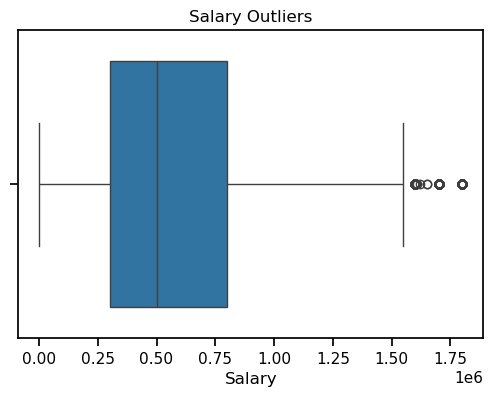

In [38]:
plt.figure(figsize=(6,4)) # to fix the size of the plot 
sns.boxplot(x = df['Salary']) # to draw a box plot and on x axis , salary 

plt.title("Salary Outliers")
plt.show() # this show us the outlier 

## IQR(interquartile range) Method 
### (commonly used Statistical technique used for detection and removing of outliers from Dataset)


In [39]:
Q1 = df['Salary'].quantile(0.25) #value below which our 25 % data lies
Q3 = df['Salary'].quantile(0.75) #value below which our 75 % data lies

IQR = Q3 - Q1

In [40]:
lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

In [41]:
df = df[(df['Salary'] >= lower_limit)  & (df['Salary'] <= upper_limit)]

In [42]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


# univariate Analysis 
### Salary Distribution (to understand one variable at a time )

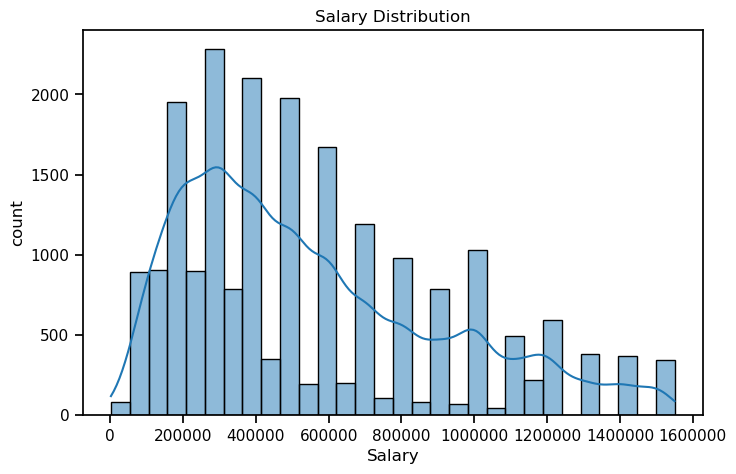

In [43]:
plt.figure(figsize = (8,5))
sns.histplot(df['Salary'], bins = 30, kde = True) # bins is the number of bars in histogram , Kde =true shows this smooth curve line ,if it is false then it don't show that line
plt.ticklabel_format(style = 'plain' , axis = 'x') # to show the values on x axis 

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("count")
plt.show()

# Answering Buisness Questions 
### Q1 which job roles have highest average salary???

In [44]:
df['Job Roles'].nunique() # this is for number of  unique values in job roles and also we use [] because job roles has space between them 

11

In [45]:
df['Job Roles'].unique() # this is for what are the unique values in job roles 

array(['Android', 'Backend', 'Database', 'Frontend', 'IOS', 'Java',
       'Mobile', 'SDE', 'Python', 'Web', 'Testing'], dtype=object)

In [46]:
Job_Salary = df.groupby("Job Roles")["Salary"].mean().sort_values(ascending = False).head(10)# to grouping the job roles ,then find mean of them ,then sort ,then show top 10 

In [47]:
Job_Salary

Job Roles
Database    702554.768392
SDE         648182.534714
IOS         593214.068241
Mobile      589857.819905
Backend     529104.564347
Frontend    501977.282203
Android     483352.318634
Java        475832.116985
Testing     464824.757895
Python      449531.694295
Name: Salary, dtype: float64

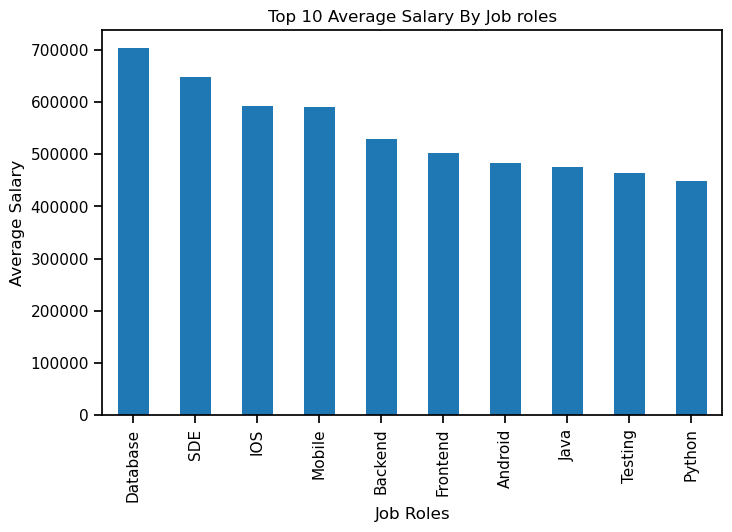

In [48]:
plt.figure(figsize = (8,5))
Job_Salary.plot(kind = 'bar')
plt.title("Top 10 Average Salary By Job roles")
plt.ylabel("Average Salary")
plt.show()

### Q2 which cities have highest average salary ??

In [49]:
df['Location'].nunique()  

10

In [50]:
 df['Location'].unique() 

array(['Bangalore', 'Chennai', 'Hyderabad', 'New Delhi', 'Pune', 'Jaipur',
       'Kerala', 'Kolkata', 'Madhya Pradesh', 'Mumbai'], dtype=object)

In [51]:
city_average = df.groupby("Location")["Salary"].mean().sort_values(ascending = False).head(10)

In [52]:
city_average

Location
Mumbai            702195.874214
Bangalore         568223.271851
Jaipur            566153.846154
Pune              562387.138833
New Delhi         542717.057751
Hyderabad         538809.567450
Kolkata           532604.938272
Kerala            514965.735849
Chennai           505102.446337
Madhya Pradesh    497530.378378
Name: Salary, dtype: float64

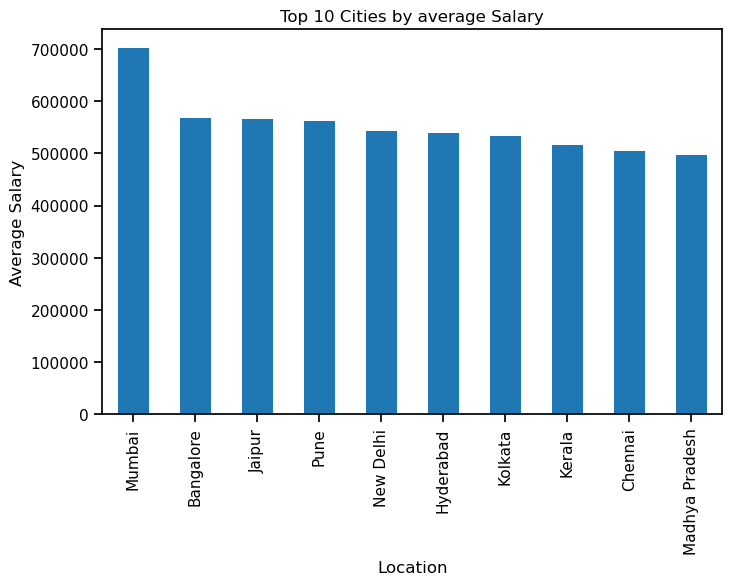

In [53]:
plt.figure(figsize = (8,5))
city_average.plot(kind = 'bar')
plt.title("Top 10 Cities by average Salary")
plt.ylabel("Average Salary")
plt.show()

### Q3 name those 5 companies located in NEW delhi with rating of '5' , offering highest and lowest salary??

In [54]:
df1 = df[(df['Location'] == 'New Delhi') & (df['Rating'] == 5)].sort_values(by = "Salary",ascending = False)

In [55]:
list(df1['Company Name'].head(5))

['Trillbit',
 'Hapramp',
 'The Art of Mike Mignola',
 'Silicon Valley Recycling',
 'Parth Universal']

In [56]:
list(df1['Company Name'].tail(5))

['Rabbler', 'WorkingNation', 'Hopin (India)', 'Star Catalysts', 'Atom 8']

### Q4 which job title has the highest number of salary reported ??

In [57]:
df 

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [58]:
 df.groupby('Job Title')['Salaries Reported'].count().sort_values(ascending = False)

Job Title
Software Development Engineer                        2137
Android Developer                                    1983
Software Development Engineer (SDE)                  1477
Front End Developer                                  1360
Test Engineer                                        1290
                                                     ... 
UI/User Experience Designer & Front End Developer       1
UI/UX Designer & Front End Developer                    1
UI Front End Developer                                  1
Trainee Test Engineer - Contractor                      1
Trainee Engineer – Software Development                 1
Name: Salaries Reported, Length: 981, dtype: int64

### Q5 which 10 companies gives highest average salary , when at least 20 employees have reported their salaries?? 

In [59]:
filtered_df = df[df['Salaries Reported'] >= 20]  

In [60]:
filtered_df.groupby("Company Name")['Salary'].mean().sort_values(ascending = False).head(10)

Company Name
Expedia Group     1.350000e+06
Nokia             1.200000e+06
Amadeus           1.200000e+06
Alcatel-Lucent    1.000000e+06
Ola               1.000000e+06
Kony              9.000000e+05
Lumen             9.000000e+05
Microsoft         7.845714e+05
Cisco Systems     7.000000e+05
McAfee            6.500000e+05
Name: Salary, dtype: float64

### Q5 check and show the relationship betweeen ratings and salaries 

In [61]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [63]:
 df.corr(numeric_only=True) # this tells the correlation between all the numerical columns of the dataset 

,Rating,Salary,Salaries Reported
Rating,1.000000,0.024772,-0.013516
Salary,0.024772,1.000000,-0.021672
Salaries Reported,-0.013516,-0.021672,1.000000


In [65]:
df['Rating'].corr(df['Salary'])

np.float64(0.024771628383435627)

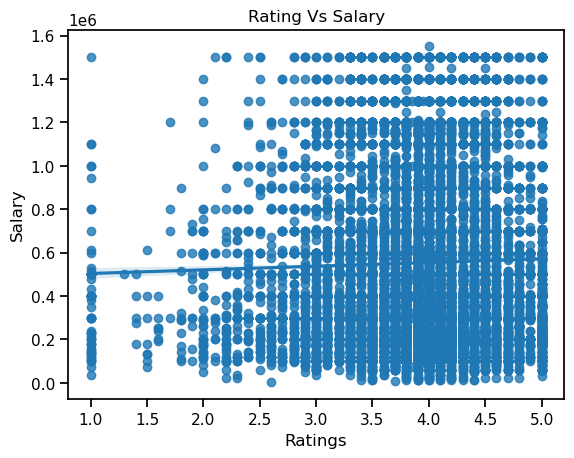

In [70]:
sns.regplot( x = 'Rating' , y = 'Salary',data = df) # it is a regression plot or sns.relplot is relative 
plt.title("Rating Vs Salary")
plt.xlabel("Ratings")
plt.ylabel("Salary")
plt.show()

### Q6 does employment status affect salary ??

In [71]:
df['Employment Status'].unique()

array(['Full Time', 'Intern', 'Contractor', 'Trainee'], dtype=object)

In [84]:
df.groupby(df['Employment Status'])['Salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Employment Status,,,,,,,,
Contractor,513.0,501507.586745,315663.813209,12000.0,300000.0,400000.0,600000.0,1500000.0
Full Time,18379.0,579305.536101,358065.460032,8448.0,300000.0,500000.0,800000.0,1550000.0
Intern,2089.0,338353.991383,264180.887035,2112.0,144000.0,264000.0,456000.0,1500000.0
Trainee,33.0,324303.030303,241096.516572,96000.0,144000.0,240000.0,400000.0,1100000.0


In [75]:
job_time = df.groupby(df['Employment Status'])['Salary'].sum().sort_values(ascending = False)

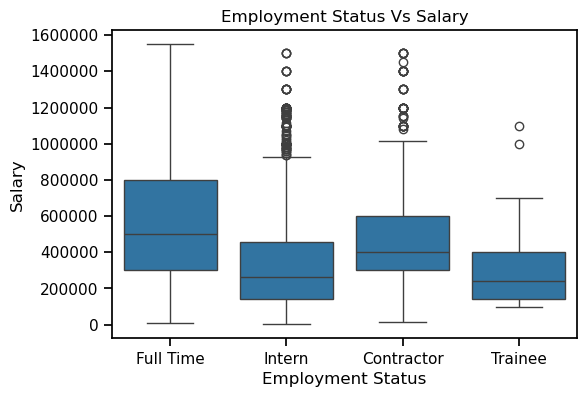

In [88]:
plt.figure(figsize = (6,4))
sns.boxplot( x = "Employment Status" , y ="Salary" , data = df)
plt.ticklabel_format(style = 'plain' , axis = 'y')
plt.title("Employment Status Vs Salary")
plt.xlabel("Employment Status")
plt.ylabel("Salary")
plt.show() # in this plot the lines in each box reprsent median and top and bottom line represent viscurves that represents the normal range 


### Q7 which job roles are most common ???

In [105]:
top_roles = df['Job Roles'].value_counts()

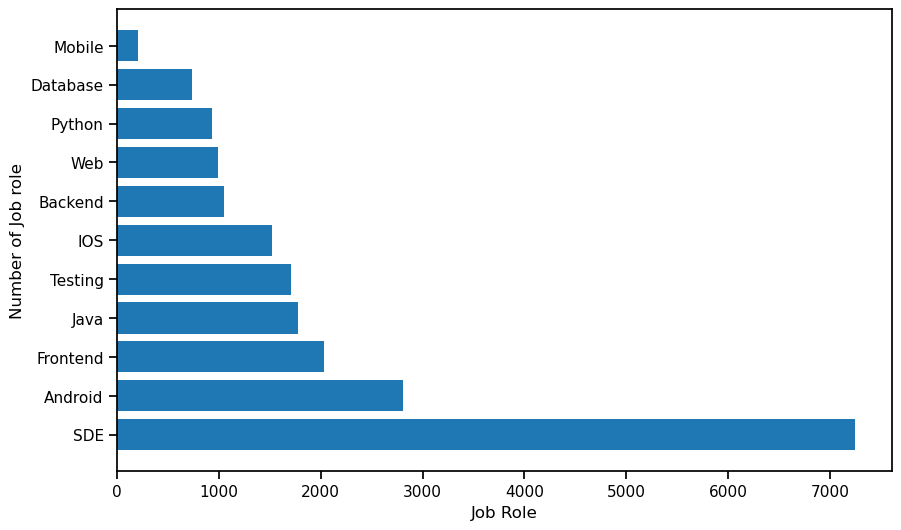

In [106]:
plt.figure(figsize = (10,6))
plt.barh(top_roles.index ,top_roles.values )
plt.xlabel("Job Role")
plt.ylabel("Number of Job role")
plt.show()